<a href="https://colab.research.google.com/github/Ridham1195/ML-Module-IIT-Projects/blob/main/finetuning_customer_support_faq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Need to install required packages.
!pip install peft trl bitsandbytes accelerate datasets sentence-transformers rouge-score nltk gradio matplotlib --quiet

In [2]:
# Verify GPU availability and print device info.
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be extremely slow.")
    print("Change runtime: Runtime -> Change runtime type -> T4 GPU")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
import os

# -- Project directories --
# All files are created under this root on the Colab runtime filesystem.
PROJECT_ROOT = "/content/faq_finetuning"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -- Dataset paths --
RAW_DATA_PATH = os.path.join(DATA_DIR, "raw_faq.jsonl")
TRAIN_DATA_PATH = os.path.join(DATA_DIR, "train.jsonl")
VAL_DATA_PATH = os.path.join(DATA_DIR, "val.jsonl")
TEST_DATA_PATH = os.path.join(DATA_DIR, "test.jsonl")

# -- Dataset generation --
TARGET_QA_PAIRS = 2000
RANDOM_SEED = 42

# -- Dataset splits --
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

# -- Model --
MODEL_NAME = "distilgpt2"
# Quantization: "4bit", "8bit", or "none"
QUANTIZATION_MODE = "4bit"

# -- LoRA (Low-Rank Adaptation) --
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
# Target the attention projection layers in GPT-2 architecture.
LORA_TARGET_MODULES = ["c_attn", "c_proj"]

# -- Training --
NUM_EPOCHS = 10
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2  # Effective batch size = 8 * 2 = 16
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 0.01
MAX_SEQ_LENGTH = 256
WARMUP_RATIO = 0.05
FP16 = True

# -- Early stopping --
EARLY_STOPPING_PATIENCE = 2

# -- Output paths --
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_model")
TRAINING_LOG_PATH = os.path.join(OUTPUT_DIR, "training_log.json")

# -- Evaluation --
NUM_MANUAL_EVAL_QUERIES = 10
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EVALUATION_RESULTS_PATH = os.path.join(OUTPUT_DIR, "evaluation_results.json")
LOSS_CURVE_PATH = os.path.join(OUTPUT_DIR, "loss_curve.png")

# -- Inference --
MAX_NEW_TOKENS = 100
TEMPERATURE = 0.7
TOP_P = 0.9
GRADIO_PORT = 7860

# -- Prompt formatting --
# Training format: model sees the full "Question: ... Answer: ..." text.
# Inference format: model sees "Question: ... Answer:" and generates the rest.
PROMPT_TEMPLATE = "Question: {question}\nAnswer: {answer}"
INFERENCE_TEMPLATE = "Question: {question}\nAnswer:"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model: {MODEL_NAME}")
print(f"Quantization: {QUANTIZATION_MODE}")
print(f"LoRA rank: {LORA_RANK}, alpha: {LORA_ALPHA}")
print(f"Training: {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, lr {LEARNING_RATE}")
print("Configuration loaded.")

Project root: /content/faq_finetuning
Model: distilgpt2
Quantization: 4bit
LoRA rank: 16, alpha: 32
Training: 10 epochs, batch 8, lr 0.0002
Configuration loaded.


In [4]:
import json
import random

def build_templates():
    """
    Returns a dictionary mapping each sub-topic to a list of
    (question_template, answer_template) tuples.
    Placeholders like {product}, {days} get filled with random values.
    """
    templates = {
        "order_tracking": [
            ("How do I track my order?",
             "You can track your order by logging into your account and visiting the 'My Orders' section. You will find a tracking link next to each order."),
            ("Where can I find my order status?",
             "Your order status is available in the 'My Orders' section of your account dashboard. You can also check the tracking email we sent after shipment."),
            ("I haven't received a tracking number yet.",
             "Tracking numbers are sent via email within 24 hours of shipment. Please check your spam folder. If you still do not see it, contact our support team."),
            ("Can I track my order without an account?",
             "Yes, you can use the tracking link provided in your order confirmation email. No account is needed to view tracking information."),
            ("My tracking shows no updates for {days} days.",
             "Tracking updates can sometimes be delayed by {days_minus} to {days} business days during transit. If there are no updates after {days_plus} days, please contact our support team."),
            ("Does my order come with real-time tracking?",
             "Yes, once your order is shipped, you will receive a tracking link that provides real-time updates on your package location."),
            ("How long does tracking take to update?",
             "Tracking information usually updates within 24 to 48 hours after your order is shipped. Allow some time for the carrier to scan your package."),
            ("My order shows delivered but I did not receive it.",
             "We are sorry to hear that. Please check with neighbors or your building management. If you still cannot locate the package, contact our support team within 48 hours."),
        ],
        "shipping": [
            ("How long does standard shipping take?",
             "Standard shipping takes {ship_days_low} to {ship_days_high} business days depending on your location."),
            ("Do you offer express shipping?",
             "Yes, we offer express shipping which delivers within {express_days} business days for an additional fee shown at checkout."),
            ("How much does shipping cost?",
             "Shipping costs depend on your order size and location. Standard shipping starts at ${ship_cost}. Orders over ${free_ship_threshold} qualify for free shipping."),
            ("Do you ship internationally?",
             "Yes, we ship to over {num_countries} countries. International shipping times and costs vary by destination and are calculated at checkout."),
            ("Can I change my shipping address after placing an order?",
             "You can update your shipping address within {change_hours} hours of placing your order. After that, the order enters processing and changes are not possible."),
            ("What carriers do you use for shipping?",
             "We partner with major carriers including USPS, FedEx, and UPS. The carrier is selected based on your location and shipping speed preference."),
            ("Is shipping available on weekends?",
             "Orders placed on weekends are processed on the next business day. Express shipping delivery counts only business days."),
            ("Why is my shipping cost so high?",
             "Shipping costs are based on package weight, dimensions, and destination. Heavier or oversized items may incur higher charges. Check if your order qualifies for free shipping."),
        ],
        "returns": [
            ("What is your return policy?",
             "We accept returns within {return_days} days of delivery. Items must be unused, in original packaging, and accompanied by a receipt or proof of purchase."),
            ("Can I return a product after {days} days?",
             "Returns are accepted within {return_days} days of delivery. Unfortunately, items returned after this period cannot be processed."),
            ("How do I initiate a return?",
             "To start a return, go to 'My Orders', select the item, and click 'Return Item'. You will receive a prepaid return shipping label via email."),
            ("Do I have to pay for return shipping?",
             "Return shipping is free for defective or incorrect items. For other returns, a flat fee of ${return_ship_cost} is deducted from your refund."),
            ("Can I exchange an item instead of returning it?",
             "Yes, you can request an exchange for a different size or color. Go to 'My Orders' and select 'Exchange' next to the item."),
            ("What items are not eligible for return?",
             "Final sale items, personalized products, perishable goods, and intimate apparel are not eligible for returns. Check the product page for return eligibility."),
            ("Can I return an item purchased during a sale?",
             "Yes, sale items can be returned within {return_days} days. However, the refund will be based on the price you paid, not the original price."),
            ("I received a damaged item. What should I do?",
             "We apologize for the inconvenience. Please contact our support team within 48 hours with photos of the damage. We will arrange a replacement or full refund."),
        ],
        "refunds": [
            ("How long does a refund take?",
             "Refunds are processed within {refund_days_low} to {refund_days_high} business days after we receive the returned item. It may take an additional {bank_days} days for the amount to appear in your account."),
            ("Can I get a refund to my original payment method?",
             "Yes, refunds are issued to the original payment method used for the purchase. This includes credit cards, debit cards, and digital wallets."),
            ("I have not received my refund yet.",
             "Refunds take {refund_days_low} to {refund_days_high} business days to process after we receive your return. If it has been longer, please contact your bank or our support team."),
            ("Can I get a refund as store credit?",
             "Yes, you can choose to receive your refund as store credit. Store credit is applied instantly and never expires."),
            ("Will I get a full refund?",
             "Full refunds are issued for items returned in their original condition within the return window. Return shipping fees may be deducted for non-defective returns."),
            ("Do you offer partial refunds?",
             "Partial refunds may be issued for items returned in used condition or outside the standard return window, at our discretion."),
            ("Can I get a refund if I used a coupon?",
             "If you used a coupon, the refund will reflect the amount you actually paid. The coupon will not be reissued."),
        ],
        "account": [
            ("How do I create an account?",
             "Click the 'Sign Up' button on our homepage and fill in your name, email, and password. You will receive a verification email to activate your account."),
            ("I forgot my password. How do I reset it?",
             "Click 'Forgot Password' on the login page. Enter your email and we will send you a password reset link. The link expires in {reset_hours} hours."),
            ("How do I update my email address?",
             "Go to 'Account Settings' and click 'Edit' next to your email. Enter your new email and verify it through the confirmation email we send."),
            ("Can I delete my account?",
             "Yes, you can request account deletion from 'Account Settings'. Please note that this action is permanent and all your order history will be removed."),
            ("How do I change my default shipping address?",
             "Go to 'Account Settings', then 'Addresses'. You can add, edit, or remove shipping addresses and set a default."),
            ("Is my personal information secure?",
             "Yes, we use industry-standard encryption and security protocols to protect your personal information. We never share your data with third parties without consent."),
            ("How do I add a payment method to my account?",
             "Go to 'Account Settings', then 'Payment Methods'. Click 'Add New' and enter your card details. Your information is encrypted and stored securely."),
            ("Can I have multiple shipping addresses?",
             "Yes, you can save multiple shipping addresses in your account. During checkout, you can select which address to use for each order."),
        ],
        "discounts": [
            ("How do I apply a discount code?",
             "Enter your discount code in the 'Promo Code' field at checkout and click 'Apply'. The discount will be reflected in your order total."),
            ("Why is my promo code not working?",
             "Please check that the code has not expired, meets the minimum order requirement, and applies to the items in your cart. Some codes cannot be combined with other offers."),
            ("Do you offer student discounts?",
             "Yes, we offer a {student_discount}% discount for verified students. Register with your university email to receive your discount code."),
            ("Can I combine multiple discount codes?",
             "Only one discount code can be applied per order. If you have multiple codes, choose the one that gives you the best savings."),
            ("When is your next sale?",
             "We run seasonal sales throughout the year. Subscribe to our newsletter to be the first to know about upcoming promotions and exclusive deals."),
            ("Do you have a loyalty program?",
             "Yes, our rewards program lets you earn {points_per_dollar} points for every dollar spent. Points can be redeemed for discounts on future purchases."),
            ("I forgot to apply my coupon. Can I get a retroactive discount?",
             "Unfortunately, we cannot apply coupons retroactively to completed orders. Please make sure to apply your code during checkout."),
            ("Do first-time customers get a discount?",
             "Yes, first-time customers receive {first_discount}% off their first order. The code is sent to your email after you create an account."),
        ],
        "products": [
            ("Is the {product} currently in stock?",
             "Stock availability changes frequently. Please check the product page for real-time availability. You can also sign up for restock notifications."),
            ("What are the dimensions of the {product}?",
             "Detailed dimensions and specifications are listed on the product page under the 'Specifications' tab. If you need further details, contact our support team."),
            ("Can I get notified when {product} is back in stock?",
             "Yes, click the 'Notify Me' button on the product page and enter your email. We will send you an alert as soon as it is restocked."),
            ("Do you have a size guide?",
             "Yes, you can find our size guide on each product page under the 'Size Guide' tab. It includes measurements in both inches and centimeters."),
            ("What materials is the {product} made of?",
             "Material information is listed on the product page under 'Details'. We provide complete material composition for all our products."),
            ("Are your products covered by a warranty?",
             "Most products come with a {warranty_months}-month manufacturer warranty. Check the product page for specific warranty information."),
            ("Can I see customer reviews for {product}?",
             "Yes, customer reviews are available at the bottom of each product page. You can filter by rating and sort by most recent or most helpful."),
        ],
        "cancellations": [
            ("How do I cancel my order?",
             "You can cancel your order from 'My Orders' within {cancel_hours} hours of placing it. After that, the order enters processing and cannot be cancelled."),
            ("Can I cancel part of my order?",
             "Yes, you can cancel individual items from your order as long as they have not entered the shipping stage. Go to 'My Orders' and select the items to cancel."),
            ("Will I be charged if I cancel my order?",
             "No, there is no cancellation fee if you cancel within the allowed window. Your payment will be fully refunded to your original payment method."),
            ("I accidentally placed a duplicate order. Can I cancel one?",
             "Yes, please cancel the duplicate order from 'My Orders' as soon as possible. If it has already shipped, you can initiate a return once you receive it."),
            ("My order was cancelled automatically. Why?",
             "Orders may be cancelled if payment verification fails, the item goes out of stock, or a pricing error is detected. You will receive an email explaining the reason."),
            ("Can I cancel a pre-order?",
             "Yes, pre-orders can be cancelled any time before they ship. Go to 'My Orders' and click 'Cancel' next to the pre-ordered item."),
        ],
        "gift_cards": [
            ("How do I redeem a gift card?",
             "Enter your gift card code in the 'Gift Card' field at checkout. The balance will be applied to your order total."),
            ("Do gift cards expire?",
             "No, our gift cards do not expire. You can use them at any time."),
            ("Can I check my gift card balance?",
             "Yes, go to 'Gift Cards' in your account settings and enter your card number to view the remaining balance."),
            ("Can I use a gift card with a discount code?",
             "Yes, gift cards and discount codes can be used together on the same order."),
            ("Can I buy a gift card for someone else?",
             "Yes, you can purchase a digital gift card and have it sent directly to the recipient's email with a personalized message."),
            ("What denominations are gift cards available in?",
             "Gift cards are available in denominations of $25, $50, $75, $100, and $150. Custom amounts are also available."),
        ],
        "technical": [
            ("The website is not loading properly.",
             "Please try clearing your browser cache and cookies, then reload the page. If the issue persists, try a different browser or device."),
            ("I cannot complete my checkout.",
             "Please ensure your payment details are correct and your billing address matches your card. Try disabling browser extensions or using a different browser."),
            ("The app keeps crashing.",
             "Please make sure you have the latest version of our app installed. If the issue continues, try uninstalling and reinstalling the app."),
            ("I am not receiving emails from you.",
             "Please check your spam or junk folder. Add our email address to your contacts to ensure future emails reach your inbox."),
            ("How do I enable push notifications?",
             "Go to your device settings, find our app, and enable notifications. You can also manage notification preferences within the app settings."),
            ("The payment page shows an error.",
             "Please try again in a few minutes. If the error persists, try a different payment method or contact your bank to ensure the transaction is not being blocked."),
        ],
    }
    return templates


def get_fill_values():
    """Returns possible values for template placeholders."""
    return {
        "days": [3, 5, 7, 10, 14],
        "ship_days_low": [3, 5],
        "ship_days_high": [7, 10, 12],
        "express_days": [1, 2, 3],
        "ship_cost": [4.99, 5.99, 7.99],
        "free_ship_threshold": [35, 50, 75],
        "num_countries": [50, 80, 100, 120],
        "change_hours": [1, 2, 4],
        "return_days": [14, 30],
        "return_ship_cost": [5.99, 7.99],
        "refund_days_low": [3, 5],
        "refund_days_high": [7, 10],
        "bank_days": [3, 5, 7],
        "reset_hours": [24, 48],
        "student_discount": [10, 15, 20],
        "points_per_dollar": [1, 2, 5],
        "first_discount": [10, 15],
        "product": [
            "wireless headphones", "running shoes", "laptop stand",
            "backpack", "water bottle", "desk lamp", "phone case",
            "yoga mat", "smartwatch", "keyboard", "office chair",
            "sunglasses", "travel mug", "bluetooth speaker"
        ],
        "warranty_months": [6, 12, 24],
        "cancel_hours": [1, 2, 4, 6],
    }


def fill_template(template_str, fill_values, rng):
    """Replace placeholders in a template with random values."""
    result = template_str
    # Handle the "days" placeholder and its derivatives.
    if "{days}" in result or "{days_minus}" in result or "{days_plus}" in result:
        days_val = rng.choice(fill_values["days"])
        result = result.replace("{days}", str(days_val))
        result = result.replace("{days_minus}", str(max(1, days_val - 2)))
        result = result.replace("{days_plus}", str(days_val + 3))
    # Replace all other placeholders.
    for key, values in fill_values.items():
        placeholder = "{" + key + "}"
        if placeholder in result:
            result = result.replace(placeholder, str(rng.choice(values)))
    return result


# -- Generate the dataset --
rng = random.Random(RANDOM_SEED)
templates = build_templates()
fill_values = get_fill_values()
qa_pairs = []

total_templates = sum(len(t) for t in templates.values())
rounds_needed = max(1, TARGET_QA_PAIRS // total_templates + 1)

print(f"Templates: {total_templates}, Rounds: {rounds_needed}")

for _ in range(rounds_needed):
    for topic, topic_templates in templates.items():
        for q_tpl, a_tpl in topic_templates:
            question = fill_template(q_tpl, fill_values, rng)
            answer = fill_template(a_tpl, fill_values, rng)
            qa_pairs.append({"prompt": question, "response": answer})

rng.shuffle(qa_pairs)
qa_pairs = qa_pairs[:TARGET_QA_PAIRS]

# Save to JSONL.
with open(RAW_DATA_PATH, "w", encoding="utf-8") as f:
    for pair in qa_pairs:
        f.write(json.dumps(pair, ensure_ascii=False) + "\n")

print(f"Generated {len(qa_pairs)} Q&A pairs -> {RAW_DATA_PATH}")

# Show a few samples.
print("\nSamples:")
for i, pair in enumerate(qa_pairs[:3]):
    print(f"  Q: {pair['prompt']}")
    print(f"  A: {pair['response']}\n")

Templates: 72, Rounds: 28
Generated 2000 Q&A pairs -> /content/faq_finetuning/data/raw_faq.jsonl

Samples:
  Q: What denominations are gift cards available in?
  A: Gift cards are available in denominations of $25, $50, $75, $100, and $150. Custom amounts are also available.

  Q: Do first-time customers get a discount?
  A: Yes, first-time customers receive 15% off their first order. The code is sent to your email after you create an account.

  Q: How do I track my order?
  A: You can track your order by logging into your account and visiting the 'My Orders' section. You will find a tracking link next to each order.



In [5]:
import json
import random
import re

def clean_text(text):
    """Normalize whitespace and remove control characters."""
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)
    text = re.sub(r" +", " ", text)
    return text.strip()

# Load raw data.
raw_data = []
with open(RAW_DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw_data.append(json.loads(line))
print(f"Loaded: {len(raw_data)} entries")

# Clean text fields.
for entry in raw_data:
    entry["prompt"] = clean_text(entry["prompt"])
    entry["response"] = clean_text(entry["response"])
raw_data = [e for e in raw_data if e["prompt"] and e["response"]]
print(f"After cleaning: {len(raw_data)}")

# Deduplicate based on lowercased prompt+response.
seen = set()
unique_data = []
for entry in raw_data:
    key = (entry["prompt"].lower(), entry["response"].lower())
    if key not in seen:
        seen.add(key)
        unique_data.append(entry)
print(f"After dedup: {len(unique_data)}")

# Format for training: combine question and answer into a single text string.
formatted_data = []
for entry in unique_data:
    text = PROMPT_TEMPLATE.format(question=entry["prompt"], answer=entry["response"])
    formatted_data.append({
        "text": text,
        "prompt": entry["prompt"],
        "response": entry["response"]
    })

# Shuffle and split.
rng = random.Random(RANDOM_SEED)
rng.shuffle(formatted_data)
n = len(formatted_data)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_data = formatted_data[:train_end]
val_data = formatted_data[train_end:val_end]
test_data = formatted_data[val_end:]

# Save splits.
for data, path, name in [
    (train_data, TRAIN_DATA_PATH, "Train"),
    (val_data, VAL_DATA_PATH, "Val"),
    (test_data, TEST_DATA_PATH, "Test"),
]:
    with open(path, "w", encoding="utf-8") as f:
        for entry in data:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")
    print(f"{name}: {len(data)} samples -> {path}")

print(f"\nSample formatted entry:\n  {formatted_data[0]['text']}")

Loaded: 2000 entries
After cleaning: 2000
After dedup: 197
Train: 157 samples -> /content/faq_finetuning/data/train.jsonl
Val: 19 samples -> /content/faq_finetuning/data/val.jsonl
Test: 21 samples -> /content/faq_finetuning/data/test.jsonl

Sample formatted entry:
  Question: My tracking shows no updates for 14 days.
Answer: Tracking updates can sometimes be delayed by 1 to 3 business days during transit. If there are no updates after 6 days, please contact our support team.


In [6]:
import trl
print(trl.__version__)

0.29.0


In [7]:
import json
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from trl import SFTTrainer, SFTConfig

# -- Load tokenizer --
print(f"Loading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# -- Load model with 4-bit quantization --
quant_config = None
if QUANTIZATION_MODE == "4bit":
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
elif QUANTIZATION_MODE == "8bit":
    quant_config = BitsAndBytesConfig(load_in_8bit=True)

model_kwargs = {"device_map": "auto"}
if quant_config:
    model_kwargs["quantization_config"] = quant_config

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **model_kwargs)
if quant_config:
    model = prepare_model_for_kbit_training(model)
model.config.pad_token_id = tokenizer.pad_token_id
print(f"Model parameters: {model.num_parameters():,}")

# -- Apply LoRA adapters --
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Force all parameters to float32 to avoid bfloat16 AMP errors on T4.
# T4 does not natively support bfloat16 and the AMP grad scaler crashes.
for name, param in model.named_parameters():
    if param.requires_grad and param.dtype != torch.float32:
        param.data = param.data.to(torch.float32)

# -- Load datasets --
train_dataset = load_dataset("json", data_files=TRAIN_DATA_PATH, split="train")
val_dataset = load_dataset("json", data_files=VAL_DATA_PATH, split="train")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# Remove extra columns so SFTTrainer only sees "text".
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c != "text"])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c != "text"])
print(f"Dataset columns: {train_dataset.column_names}")

# -- SFTConfig for trl 0.29+ --
# Disable both fp16 and bf16 to avoid AMP dtype conflicts with quantized models.
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    fp16=False,
    bf16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=10,
    logging_first_step=True,
    report_to="none",
    seed=RANDOM_SEED,
    dataset_text_field="text",
)

# -- Early stopping: stop if val loss does not improve for 2 epochs --
early_stopping = EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)

# -- Create trainer and train --
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=sft_config,
    callbacks=[early_stopping],
)

print(f"\nStarting training...")
print(f"  Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, Effective batch: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  LR: {LEARNING_RATE}, Early stopping patience: {EARLY_STOPPING_PATIENCE}\n")

train_result = trainer.train()

# -- Save the best model --
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f"\nBest model saved to: {BEST_MODEL_DIR}")

# -- Save training log --
with open(TRAINING_LOG_PATH, "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)
print(f"Training log saved to: {TRAINING_LOG_PATH}")

print(f"\nTraining complete.")
print(f"  Total steps: {trainer.state.global_step}")
print(f"  Best eval loss: {trainer.state.best_metric:.4f}")

Loading model: distilgpt2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 81,912,576
trainable params: 811,008 || all params: 82,723,584 || trainable%: 0.9804


...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.



Starting training...
  Epochs: 10, Batch: 8, Effective batch: 16
  LR: 0.0002, Early stopping patience: 2



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.510017,2.982095
2,3.198936,2.630713
3,2.838521,2.434308
4,2.635334,2.305197
5,2.485732,2.211273
6,2.370801,2.140809
7,2.280287,2.091050
8,2.230468,2.060872
9,2.210788,2.043674
10,2.178653,2.039620



Best model saved to: /content/faq_finetuning/outputs/best_model
Training log saved to: /content/faq_finetuning/outputs/training_log.json

Training complete.
  Total steps: 100
  Best eval loss: 2.0396


In [8]:
import json
import os
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)


def generate_response(model, tokenizer, question):
    """Generate a response for a question using the given model."""
    prompt = INFERENCE_TEMPLATE.format(question=question)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    # Stop at the next "Question:" if model generates another Q&A pair.
    if "Question:" in response:
        response = response[:response.index("Question:")].strip()
    return response


# -- Load base model --
print("Loading base model...")
base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_tokenizer.pad_token = base_tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")
base_model.eval()

# -- Load fine-tuned model --
print("Loading fine-tuned model...")
ft_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")
ft_model = PeftModel.from_pretrained(ft_base, BEST_MODEL_DIR)
ft_model.eval()

# -- Load embedding model for cosine similarity --
print("Loading embedding model...")
embed_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

# -- Load test data --
test_entries = []
with open(TEST_DATA_PATH, "r") as f:
    for line in f:
        if line.strip():
            test_entries.append(json.loads(line))
eval_queries = test_entries[:NUM_MANUAL_EVAL_QUERIES]

print(f"\nEvaluating {len(eval_queries)} test queries...\n")

# -- Evaluate each query --
smoothie = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
results = []

for i, entry in enumerate(eval_queries):
    question = entry["prompt"]
    reference = entry["response"]

    base_resp = generate_response(base_model, base_tokenizer, question)
    ft_resp = generate_response(ft_model, ft_tokenizer, question)

    # BLEU
    ref_tok = reference.lower().split()
    base_bleu = sentence_bleu([ref_tok], base_resp.lower().split(), smoothing_function=smoothie) if base_resp else 0.0
    ft_bleu = sentence_bleu([ref_tok], ft_resp.lower().split(), smoothing_function=smoothie) if ft_resp else 0.0

    # ROUGE-L
    base_rouge = rouge.score(reference, base_resp)["rougeL"].fmeasure
    ft_rouge = rouge.score(reference, ft_resp)["rougeL"].fmeasure

    # Cosine similarity
    ref_emb = embed_model.encode(reference, convert_to_tensor=True)
    base_cos = util.cos_sim(ref_emb, embed_model.encode(base_resp, convert_to_tensor=True)).item()
    ft_cos = util.cos_sim(ref_emb, embed_model.encode(ft_resp, convert_to_tensor=True)).item()

    results.append({
        "query_index": i + 1,
        "question": question,
        "reference_answer": reference,
        "base_model_response": base_resp,
        "finetuned_model_response": ft_resp,
        "base_metrics": {"bleu": round(base_bleu, 4), "rouge_l": round(base_rouge, 4), "cosine_similarity": round(base_cos, 4)},
        "finetuned_metrics": {"bleu": round(ft_bleu, 4), "rouge_l": round(ft_rouge, 4), "cosine_similarity": round(ft_cos, 4)},
    })

    print(f"--- Query {i+1}/{len(eval_queries)} ---")
    print(f"  Question:   {question}")
    print(f"  Expected:   {reference[:100]}...")
    print(f"  Base:       {base_resp[:100]}...")
    print(f"  Fine-tuned: {ft_resp[:100]}...")
    print(f"  Base   BLEU={base_bleu:.3f}  ROUGE-L={base_rouge:.3f}  Cosine={base_cos:.3f}")
    print(f"  FT     BLEU={ft_bleu:.3f}  ROUGE-L={ft_rouge:.3f}  Cosine={ft_cos:.3f}")
    print()

# -- Aggregate metrics --
base_avg = {
    "avg_bleu": round(np.mean([r["base_metrics"]["bleu"] for r in results]), 4),
    "avg_rouge_l": round(np.mean([r["base_metrics"]["rouge_l"] for r in results]), 4),
    "avg_cosine_similarity": round(np.mean([r["base_metrics"]["cosine_similarity"] for r in results]), 4),
}
ft_avg = {
    "avg_bleu": round(np.mean([r["finetuned_metrics"]["bleu"] for r in results]), 4),
    "avg_rouge_l": round(np.mean([r["finetuned_metrics"]["rouge_l"] for r in results]), 4),
    "avg_cosine_similarity": round(np.mean([r["finetuned_metrics"]["cosine_similarity"] for r in results]), 4),
}

print("=" * 65)
print("EVALUATION SUMMARY")
print("=" * 65)
print(f"{'Metric':<25} {'Base Model':>15} {'Fine-Tuned':>15}")
print("-" * 65)
print(f"{'Avg BLEU':<25} {base_avg['avg_bleu']:>15.4f} {ft_avg['avg_bleu']:>15.4f}")
print(f"{'Avg ROUGE-L':<25} {base_avg['avg_rouge_l']:>15.4f} {ft_avg['avg_rouge_l']:>15.4f}")
print(f"{'Avg Cosine Similarity':<25} {base_avg['avg_cosine_similarity']:>15.4f} {ft_avg['avg_cosine_similarity']:>15.4f}")
print("=" * 65)

# -- Save results --
eval_output = {
    "num_queries": len(eval_queries),
    "aggregate_metrics": {"base_model": base_avg, "finetuned_model": ft_avg},
    "per_query_results": results,
}
with open(EVALUATION_RESULTS_PATH, "w") as f:
    json.dump(eval_output, f, indent=2)
print(f"\nResults saved to: {EVALUATION_RESULTS_PATH}")

# -- Plot loss curve --
if os.path.exists(TRAINING_LOG_PATH):
    with open(TRAINING_LOG_PATH, "r") as f:
        log_history = json.load(f)

    train_steps = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
    train_losses = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
    eval_steps = [e["step"] for e in log_history if "eval_loss" in e]
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

    fig, ax = plt.subplots(figsize=(10, 6))
    if train_steps:
        ax.plot(train_steps, train_losses, label="Training Loss", color="blue", alpha=0.7)
    if eval_steps:
        ax.plot(eval_steps, eval_losses, label="Validation Loss", color="red", marker="o", linewidth=2)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel("Loss")
    ax.set_title("Training vs Validation Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(LOSS_CURVE_PATH, dpi=150)
    plt.close()
    print(f"Loss curve saved to: {LOSS_CURVE_PATH}")

Loading base model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading fine-tuned model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating 10 test queries...

--- Query 1/10 ---
  Question:   Can I see customer reviews for office chair?
  Expected:   Yes, customer reviews are available at the bottom of each product page. You can filter by rating and...
  Base:       I can see customer reviews for office chair....
  Fine-tuned: Yes, we can see customer reviews for office chairs. We provide reviews for items that are not review...
  Base   BLEU=0.008  ROUGE-L=0.121  Cosine=0.503
  FT     BLEU=0.021  ROUGE-L=0.208  Cosine=0.639

--- Query 2/10 ---
  Question:   How do I add a payment method to my account?
  Expected:   Go to 'Account Settings', then 'Payment Methods'. Click 'Add New' and enter your card details. Your ...
  Base:       I can't add any payment method to my account.
I just use PayPal to send money to my account. If I ha...
  Fine-tuned: By adding an account to your account, you can add a payment method to your account. You can also add...
  Base   BLEU=0.003  ROUGE-L=0.110  Cosine=0.466
  FT     BLE

### Display the loss curve


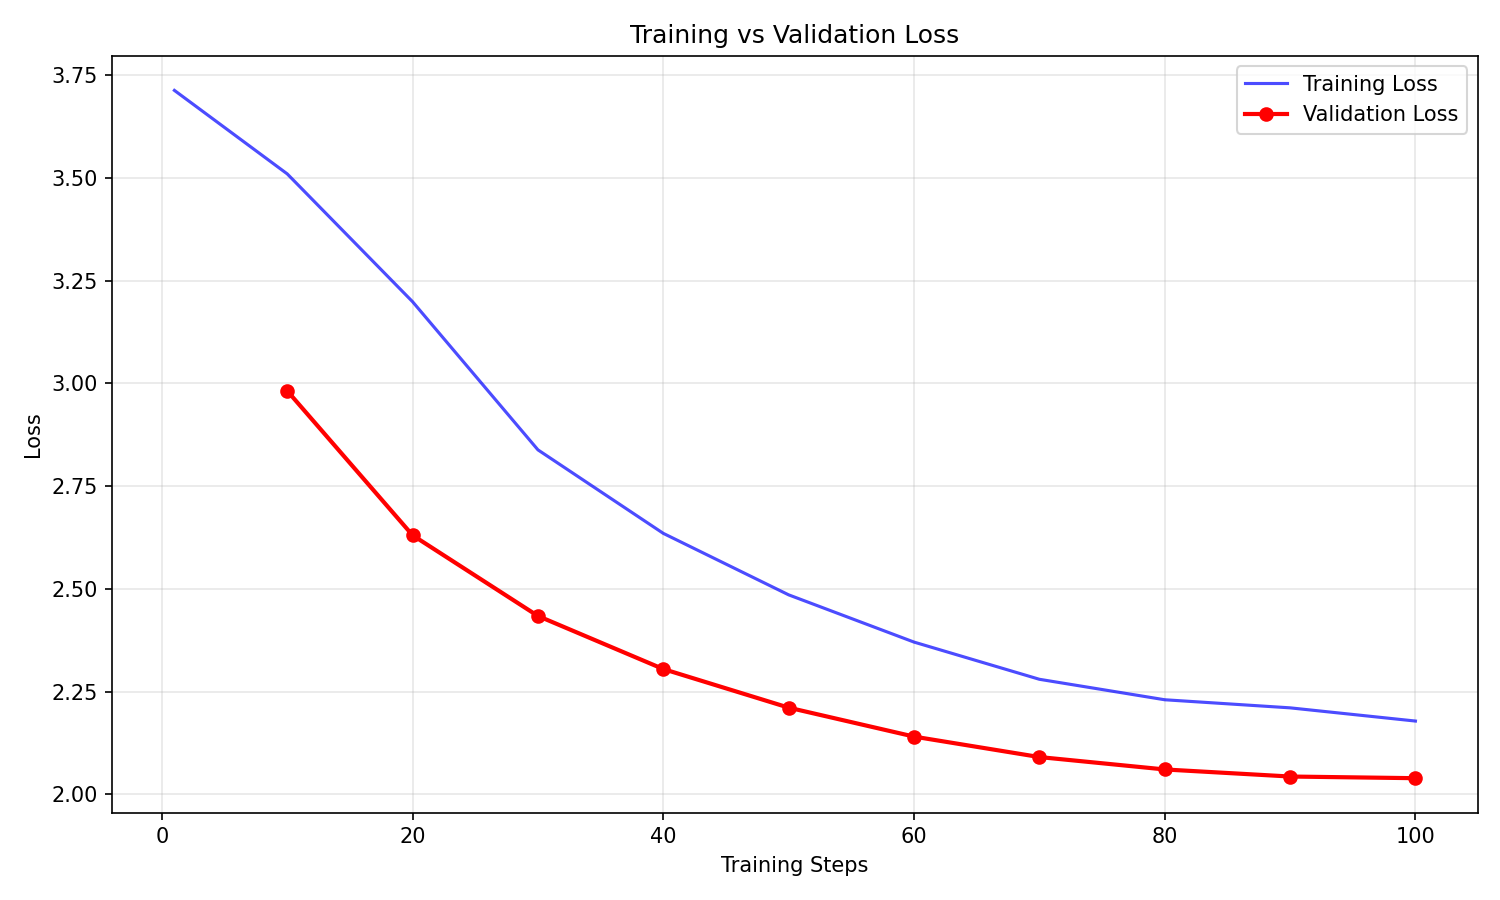

In [9]:
from IPython.display import Image, display
import os

if os.path.exists(LOSS_CURVE_PATH):
    display(Image(filename=LOSS_CURVE_PATH))
else:
    print("Loss curve not found.")

In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import gradio as gr

# Load the fine-tuned model for inference.
print("Loading fine-tuned model...")
inf_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
inf_tokenizer.pad_token = inf_tokenizer.eos_token
inf_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")
inf_model = PeftModel.from_pretrained(inf_base, BEST_MODEL_DIR)
inf_model.eval()
print("Model ready.")


def generate_answer(question, temperature, max_tokens):
    """Generate an answer for a customer question."""
    if not question.strip():
        return "Please enter a question."
    prompt = INFERENCE_TEMPLATE.format(question=question)
    inputs = inf_tokenizer(prompt, return_tensors="pt").to(inf_model.device)
    with torch.no_grad():
        outputs = inf_model.generate(
            **inputs,
            max_new_tokens=int(max_tokens),
            temperature=temperature,
            top_p=TOP_P,
            do_sample=True,
            pad_token_id=inf_tokenizer.pad_token_id,
            repetition_penalty=1.2,
        )
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    answer = inf_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    if "Question:" in answer:
        answer = answer[:answer.index("Question:")].strip()
    return answer


# Build and launch Gradio interface.
examples = [
    ["How do I track my order?"],
    ["Can I return a product after 30 days?"],
    ["How long does a refund take?"],
    ["Do you offer express shipping?"],
    ["How do I apply a discount code?"],
    ["I forgot my password. How do I reset it?"],
    ["What is your return policy?"],
    ["Do gift cards expire?"],
]

interface = gr.Interface(
    fn=generate_answer,
    inputs=[
        gr.Textbox(label="Customer Question", placeholder="Type your question here...", lines=2),
        gr.Slider(minimum=0.1, maximum=1.5, value=0.7, step=0.1, label="Temperature"),
        gr.Slider(minimum=20, maximum=200, value=100, step=10, label="Max Tokens"),
    ],
    outputs=gr.Textbox(label="Model Response", lines=4),
    title="E-Commerce Customer Support FAQ Bot",
    description="Fine-tuned DistilGPT-2 for e-commerce FAQ answering.",
    examples=examples,
    allow_flagging="never",
)

interface.launch(server_port=GRADIO_PORT, share=True, quiet=False)

Loading fine-tuned model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Model ready.


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4ea221bf8df2777db6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Pipeline Complete

All outputs are saved at `/content/faq_finetuning/outputs/`:
- `best_model/` -- Saved LoRA adapter weights
- `evaluation_results.json` -- Full evaluation metrics per query and aggregated
- `loss_curve.png` -- Training vs validation loss plot
- `training_log.json` -- Step-by-step loss history

To preserve outputs across sessions, copy to Google Drive:
```python
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/faq_finetuning/outputs /content/drive/MyDrive/
```
